<table style="display: inline-block">
 <tr>
     <td>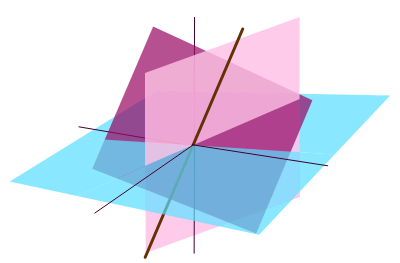</td>  
     <td style="text-align: left">
      <div style="font-size: 20pt; float: left;">Lineare Algebra und Geometrie</div><br>
      <div style="font-size: 20pt;">FS 2021</div><br>
      <div style="font-size: 15pt; margin-top: 10px;">Lucia Di Caro, Cédric Huwyler</div>
     </td>
 </tr>
</table>

# Lösungen zu den Python-Aufgaben in Übung 4

In [1]:
import numpy as np
import sympy as sp

## Aufgabe 4


In [2]:
# symbolic matrix size
n = sp.symbols('n', integer=True, positive=True)

# define symbolic matrices
A = sp.MatrixSymbol('A', n, n)
B = sp.MatrixSymbol('B', n, n)
C = sp.MatrixSymbol('C', n, n)
D = sp.MatrixSymbol('D', n, n)
X = sp.MatrixSymbol('X', n, n)



In [3]:
# -------------------------
# (a) Solve: D*X*A*C - D = D*X*B
# -------------------------
# D*X*A*C - D = D*X*B
# D*X*A*C - D*X*B = D
# D*X*(A*C - B) = D
# X*(A*C - B) = I
# X = (A*C - B)^(-1)

Xa = (A*C - B)**-1
print("(a) X =")
sp.pprint(Xa)

(a) X =
          -1
(-B + A⋅C)  


In [4]:
# -------------------------
# (b1) When does (A+B)(A-B) = A^2 - B^2 ?
# -------------------------
left_b1 = sp.expand((A + B)*(A - B))
print("(b1) (A+B)(A-B) expanded:")
sp.pprint(left_b1)
print()

print("Condition:")
print("(A+B)(A-B) = A^2 - B^2 only if A*B = B*A")

(b1) (A+B)(A-B) expanded:
  2               2
-B  + B⋅A -A⋅B + A 

Condition:
(A+B)(A-B) = A^2 - B^2 only if A*B = B*A


In [5]:
# -------------------------
# (b2) Expand (A+B)^3
# -------------------------
# Because matrices do not generally commute, do NOT use binomial formula directly.
expr_b2 = (A + B)*(A + B)*(A + B)
expr_b2_expanded = sp.expand(expr_b2)

print("(b2) (A+B)^3 expanded:")
sp.pprint(expr_b2_expanded)

(b2) (A+B)^3 expanded:
       3
(A + B) 


In [6]:
# -------------------------
# (c) Solve: A*X + B^2 = B*X + A^2
# -------------------------
# A*X - B*X = A^2 - B^2
# (A-B)*X = A^2 - B^2
# X = (A-B)^(-1) * (A^2 - B^2)

Xc = (A - B)**-1 * (A**2 - B**2)
print("(c) X =")
sp.pprint(Xc)


(c) X =
        -1 ⎛  2    2⎞
(-B + A)  ⋅⎝-B  + A ⎠


In [7]:
# -------------------------
# (d) Simplify: C^T * ( (AB)^(-1) * (C*A^T)^T )^(-1)
# -------------------------
expr_d = C.T * (((A*B)**-1 * (C*A.T).T) ** -1)
expr_d_simplified = sp.simplify(expr_d)

print("(d) simplified =")
sp.pprint(expr_d_simplified)

(d) simplified =
B


In [8]:
# Manual result:
# (C*A^T)^T = A*C^T
# ((AB)^(-1) * A*C^T)^(-1)
# = (A*C^T)^(-1) * ((AB)^(-1))^(-1)
# = (C^T)^(-1) * A^(-1) * A*B
# = (C^T)^(-1) * B
# then C^T * (C^T)^(-1) * B = B

print("Expected result for (d): B")
print()

# -------------------------
# (e) Simplify: (((A^(-1)B)^(-1) C)^(-1)) * B^(-1) * (C*A)
# -------------------------
expr_e = ((((A**-1 * B)**-1) * C) ** -1) * B**-1 * (C*A)
expr_e_simplified = sp.simplify(expr_e)

print("(e) simplified =")
sp.pprint(expr_e_simplified)

Expected result for (d): B

(e) simplified =
 -1  -1    
C  ⋅A  ⋅C⋅A


In [9]:
# Manual result:
# (A^(-1)B)^(-1) = B^(-1)A
# so (((A^(-1)B)^(-1) C)^(-1)) = (B^(-1) A C)^(-1)
# = C^(-1) A^(-1) B
# then:
# C^(-1) A^(-1) B * B^(-1) * C * A
# = C^(-1) A^(-1) C A

print("Expected result for (e): C^(-1) * A^(-1) * C * A")

Expected result for (e): C^(-1) * A^(-1) * C * A


## Aufgabe 5

Funktionen aus dem Übungsblatt 2:

In [10]:
def skalare_multiplikation( M, zeile, skalar ):
    """
    Multipliziert die Zeile <zeile> der Matrix M mit dem 
    Wert <skalar> und gibt das Resultat zurück.
    """
    
    M = M.copy()
    M[zeile,:] = M[zeile,:] * skalar
    
    return M

In [11]:
def vertausche( M, zeile1, zeile2 ):
    """
    Vertauscht die Zeile <zeile1> der Matrix M mit der 
    Zeile <zeile2> und gibt das Resultat zurück.
    """

    M = M.copy()
    tmp = M[zeile1,:].copy()
    M[zeile1,:] = M[zeile2,:]
    M[zeile2,:] = tmp
    
    return M

In [12]:
def addiere( M, zeile1, zeile2, k ):
    """
    Addiert <k> mal die Zeile <zeile2> zur Zeile <zeile1> dazu und gibt das Resultat zurück.
    """
    
    M = M.copy()
    M[zeile1,:] += k*M[zeile2,:]

    return M

### a) Speichern der Koeffizientenmatrix und erzeugen der super-erweiterten Koeffizientenmatrix

In [13]:
A = np.array([[4,1,8],[2,-1,3],[1,0,2]], dtype=np.float)
A

/var/folders/rv/pcnzwww942gfmb783p6lj7g40000gn/T/ipykernel_20461/4061718994.py:1: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  A = np.array([[4,1,8],[2,-1,3],[1,0,2]], dtype=np.float)


array([[ 4.,  1.,  8.],
       [ 2., -1.,  3.],
       [ 1.,  0.,  2.]])

In [14]:
A_se = np.hstack( [A, np.eye(3)] )
A_se

array([[ 4.,  1.,  8.,  1.,  0.,  0.],
       [ 2., -1.,  3.,  0.,  1.,  0.],
       [ 1.,  0.,  2.,  0.,  0.,  1.]])

### b) Erzeugen einer Einheitsmatrix auf der linken Seite der super-erweiterten Koeffizientenmatrix

Vertausche erste und dritte Zeile:

In [15]:
A_se = vertausche( A_se, 0, 2 )
A_se

array([[ 1.,  0.,  2.,  0.,  0.,  1.],
       [ 2., -1.,  3.,  0.,  1.,  0.],
       [ 4.,  1.,  8.,  1.,  0.,  0.]])

Erzeuge Nullen in erster Spalte:

In [16]:
A_se = addiere( A_se, 1, 0, -2 )
A_se = addiere( A_se, 2, 0, -4 )
A_se

array([[ 1.,  0.,  2.,  0.,  0.,  1.],
       [ 0., -1., -1.,  0.,  1., -2.],
       [ 0.,  1.,  0.,  1.,  0., -4.]])

Erzeuge Nullen in zweiter Spalte:

In [17]:
A_se = addiere( A_se, 2, 1, 1 )
A_se

array([[ 1.,  0.,  2.,  0.,  0.,  1.],
       [ 0., -1., -1.,  0.,  1., -2.],
       [ 0.,  0., -1.,  1.,  1., -6.]])

Erzeuge Nullen in dritter Spalte:

In [18]:
A_se = addiere( A_se, 1, 2, -1 )
A_se = addiere( A_se, 0, 2, 2 )
A_se

array([[  1.,   0.,   0.,   2.,   2., -11.],
       [  0.,  -1.,   0.,  -1.,   0.,   4.],
       [  0.,   0.,  -1.,   1.,   1.,  -6.]])

Multipliziere zweite und dritte Zeile mit -1:

In [19]:
A_se = skalare_multiplikation( A_se, 1, -1 )
A_se = skalare_multiplikation( A_se, 2, -1 )
A_se

array([[  1.,   0.,   0.,   2.,   2., -11.],
       [ -0.,   1.,  -0.,   1.,  -0.,  -4.],
       [ -0.,  -0.,   1.,  -1.,  -1.,   6.]])

### c) Inverse extrahieren und auf Korrektheit prüfen

Extrahiere Inverse:

In [20]:
A_inv = A_se[:,3:]
A_inv

array([[  2.,   2., -11.],
       [  1.,  -0.,  -4.],
       [ -1.,  -1.,   6.]])

Prüfe mit Matrizenmultiplikation mit A:

In [21]:
A.dot( A_inv )

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

## Aufgabe 6

## Invertierung mit Numpy

### a) Koeffizientenmatrizen und Spaltenvektoren bestimmen

In [22]:
A1 = np.array([[7,-2,-3],[-5,1,2],[-3,1,1]])
A1

array([[ 7, -2, -3],
       [-5,  1,  2],
       [-3,  1,  1]])

In [23]:
b1 = np.array([[2],[0],[-1]])
b1

array([[ 2],
       [ 0],
       [-1]])

In [24]:
A2 = np.array([[2,3,4],[3,4,5],[4,5,6]])
A2

array([[2, 3, 4],
       [3, 4, 5],
       [4, 5, 6]])

In [25]:
b2 = np.array([[0],[0],[0]])
b2

array([[0],
       [0],
       [0]])

### b) Ränge der Koeffizientenmatrizen / erweiterten Koeffizientenmatrizen

In [26]:
Ahat1 = np.hstack( [A1, b1] )
Ahat1

array([[ 7, -2, -3,  2],
       [-5,  1,  2,  0],
       [-3,  1,  1, -1]])

In [27]:
Ahat2 = np.hstack( [A2, b2] )
Ahat2

array([[2, 3, 4, 0],
       [3, 4, 5, 0],
       [4, 5, 6, 0]])

In [28]:
print( "rang(A1) = {}, rang(Ahat1) = {}".format( np.linalg.matrix_rank(A1), np.linalg.matrix_rank(Ahat1) ) )

rang(A1) = 3, rang(Ahat1) = 3


$\Rightarrow$ genau eine Lösung

In [29]:
print( "rang(A2) = {}, rang(Ahat2) = {}".format( np.linalg.matrix_rank(A2), np.linalg.matrix_rank(Ahat2) ) )

rang(A2) = 2, rang(Ahat2) = 2


$\Rightarrow$ unendlich viele Lösungen

### c) Bestimmung der Lösung mit Inverser

Erstes Gleichungssystem:

In [30]:
x1 = np.linalg.inv(A1).dot(b1)
x1

array([[-1.],
       [-3.],
       [-1.]])

Prüfen (Rundung des Resultats auf 10 Stellen hinter Komma wegen kleinen numerischen Fehlern):

In [31]:
np.round( A1.dot(x1) - b1, 10 )

array([[ 0.],
       [ 0.],
       [-0.]])

Die Matrix des zweiten Gleichungssystems ist nicht invertierbar, da sie nur Rang 2 besitzt:

In [33]:
np.linalg.pinv(A2)

array([[-1.33333333e+00, -1.66666667e-01,  1.00000000e+00],
       [-1.66666667e-01,  1.45302729e-18,  1.66666667e-01],
       [ 1.00000000e+00,  1.66666667e-01, -6.66666667e-01]])